In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from rubin_scheduler.scheduler.utils import CurrentAreaMap

from rubin_scheduler.utils import DEFAULT_NSIDE, SURVEY_START_MJD, hpid2_ra_dec, Site
from os.path import basename


In [2]:
nside = 128
n_needed=4

In [3]:
def read_sim(dbfile):
    run_name = basename(db_file).replace('.db', '')
    con = sqlite3.connect(db_file)
    df = pd.read_sql('select * from observations;', con)
    con.close()
    # Convert to a numpy array
    visits_array = df.to_records(index=False)
    return visits_array, run_name

In [4]:
sag = CurrentAreaMap(nside=nside)
sky_maps, labels = sag.return_maps()

# 
bands = np.zeros(sky_maps["r"].size, dtype='<U6')
n_bands = sky_maps["r"] * 0
for key in sky_maps.dtype.names:
    ack = sky_maps[key]*0
    indx = np.where(sky_maps[key] > 0)[0]
    ack[indx] = 1
    n_bands += ack
    bands[indx] = np.char.add(bands[indx], key)


indx = np.where(labels != '')[0]
fp_area = indx.size * hp.nside2pixarea(nside, degrees=True)


In [5]:
def seeing_limit_by_dec(nside=128, zenith_fwhm_limit=1.0):
    """Make a seeing limit value a function of declination
    """
    site = Site("LSST")
    hpid = np.arange(hp.nside2npix(nside))
    ra, dec = hpid2_ra_dec(nside, hpid)
    min_z = np.radians(np.abs(dec - site.latitude))
    min_airmass = 1 / np.cos(min_z)
    min_fwhm = zenith_fwhm_limit * (np.power(min_airmass, 0.6))

    # Get rid of NaNs that might be there
    min_fwhm[~np.isfinite(min_fwhm)] = 0

    return min_fwhm


In [6]:
fwhm_template_max = 1.2


In [7]:

class TemplateTime(maf.BaseMetric):
    def __init__(self, col="night", unit="MJD", name="TemplateTime",
                 bands='ugrizy', seeing_limit=1.2, nside=128, n_needed=6,
    seeing_col="seeingFwhmEff", band_col="band", night_col="night", 
                 mjd_col="observationStartMJD", footprints=None):
        super().__init__(col=col, unit=unit, name=name)
        self.seeing_limit = seeing_limit_by_dec(nside=nside, zenith_fwhm_limit=seeing_limit)
        if np.size(bands) == 1:
            self.bands = np.zeros(hp.nside2npix(nside), dtype=str)
            self.bands = np.char.add(self.bands, bands)
        else:
            self.bands = bands
        self.seeing_col = seeing_col
        self.band_col = band_col
        self.night_col = night_col
        self.mjd_col = mjd_col
        self.n_needed = n_needed
        self.badval = np.nan
        self.footprints = footprints

    def __call__(self, visits, slice_point=None):
        visits.sort(order=self.mjd_col)
        seeing_limit = self.seeing_limit[slice_point["sid"]]
        night_maxes = []
        
        for bandname in self.bands[slice_point["sid"]]:
            fp_good = True
            if self.footprints is not None:
                if self.footprints[bandname][slice_point["sid"]] == 0:
                    fp_good = False
            indx = np.where((visits[self.band_col] == bandname) 
                            & (visits[self.seeing_col] <= seeing_limit))[0]
            if (np.size(indx) >= self.n_needed) & (fp_good):
                night_maxes.append(visits[self.night_col][indx[self.n_needed - 1]])
            else:
                night_maxes.append(self.badval)

        if np.size(night_maxes) > 0:
            result = np.max(night_maxes)
        else:
            result = self.badval
        
        return result

In [8]:
db_files = ["comp_survey_v5.3.0_10yrs.db",
            "comp_survey_v5.2.0_10yrs.db",
            "../faster_templates/faster_templates_v5.3.0_10yrs.db"
           ]
arrays = {}
infos = {}



for db_file in db_files:
    visits_array, run_name = read_sim(db_file)
    
    info = {"run_name": run_name}
    sub_data = visits_array[np.where(visits_array["visitExposureTime"] >=19.)]
    info["observations_subset"] = "expt > 19s"
    sl = maf.Slicer(nside=nside)
    # XXX--setting to 4 for now to try and cut down the missing area a bit
    metric = TemplateTime(nside=nside, n_needed=n_needed, bands=bands, footprints=sky_maps)
    hp_array, info = sl(visits_array, metric, info=info)
    arrays[run_name] = hp_array
    infos[run_name] = info


In [9]:
#hp.mollview(hp_array, max=1200, min=30)

In [10]:
#hp.mollview(seeing_limit_by_dec(nside=nside, zenith_fwhm_limit=1.2), max=2, min=1.2, title="seeing limit")

In [11]:
arrays

{'comp_survey_v5.3.0_10yrs': array([ nan,  nan,  nan, ..., 202., 242., 197.], shape=(196608,)),
 'comp_survey_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 314., 190., 338.], shape=(196608,)),
 'faster_templates_v5.3.0_10yrs': array([ nan,  nan,  nan, ..., 112., 141., 120.], shape=(196608,))}

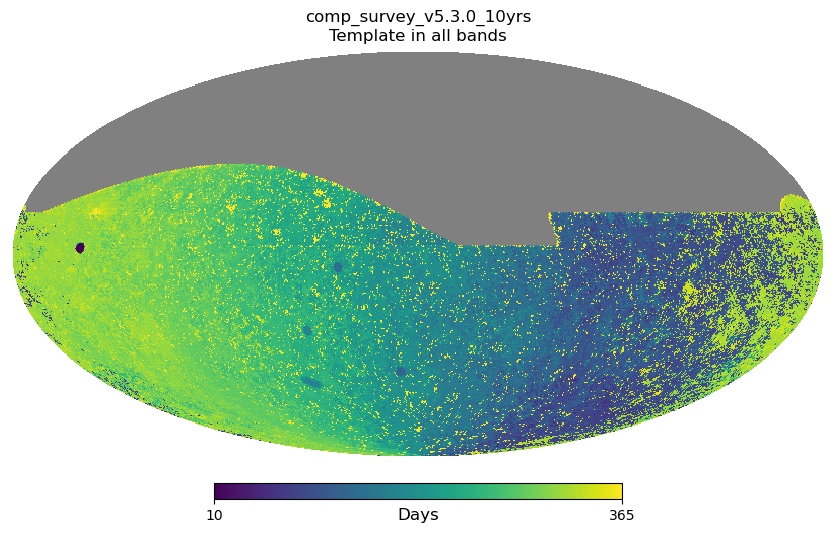

In [12]:
hp.mollview(arrays["comp_survey_v5.3.0_10yrs"], max=365, unit="Days", title="comp_survey_v5.3.0_10yrs\nTemplate in all bands")

In [13]:
#hp.mollview(arrays["dyna_clean_v5.2.0_1yrs"], max=365)

In [14]:
arrays

{'comp_survey_v5.3.0_10yrs': array([ nan,  nan,  nan, ..., 202., 242., 197.], shape=(196608,)),
 'comp_survey_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 314., 190., 338.], shape=(196608,)),
 'faster_templates_v5.3.0_10yrs': array([ nan,  nan,  nan, ..., 112., 141., 120.], shape=(196608,))}

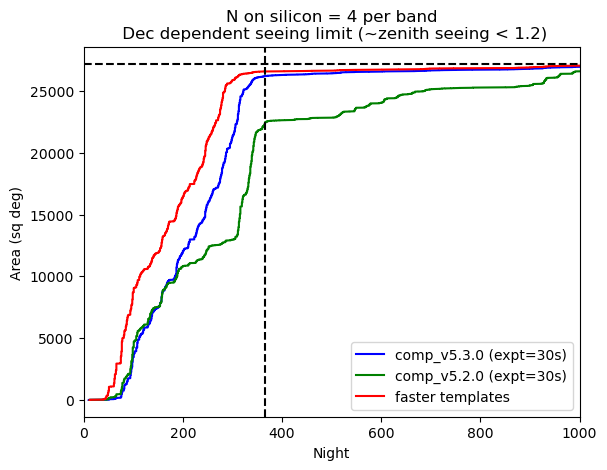

In [15]:
fig, ax = plt.subplots()

ar2label = {'comp_survey_v5.3.0_10yrs': "comp_v5.3.0 (expt=30s)",
           'comp_survey_v5.2.0_10yrs': "comp_v5.2.0 (expt=30s)",
           "faster_templates_v5.3.0_10yrs": "faster templates"}

colors = ['blue', 'green', 'red']

for key,co in zip(ar2label, colors):
    ack = arrays[key] +0 
    ack = np.sort(ack)
    ax.plot(ack, np.arange(ack.size)*hp.nside2pixarea(nside, degrees=True), label=ar2label[key], color=co)
ax.set_xlim([0,1000])
ax.set_xlabel("Night")
ax.set_ylabel("Area (sq deg)")
ax.set_title("N on silicon = %i per band\n Dec dependent seeing limit (~zenith seeing < 1.2)" % n_needed)
leg = ax.legend()
ax.axvline(x=365, linestyle="--", color="k")
ax.axhline(y=fp_area, linestyle="--", color="k")

In [16]:
n_y1 = np.where((arrays["comp_survey_v5.3.0_10yrs"] < 366) & (n_bands > 0) )[0].size
n_tot = np.sum(n_bands > 0)
print(n_y1/n_tot)

0.9633962817475323


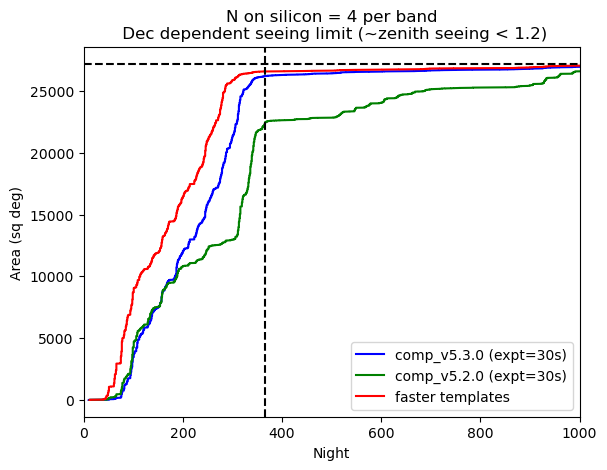

In [17]:
fig, ax = plt.subplots()


for key,co in zip(ar2label, colors):
    ack = arrays[key] +0 
    ack = np.sort(ack)
    ax.plot(ack, np.arange(ack.size)*hp.nside2pixarea(nside, degrees=True), label=ar2label[key], color=co)
ax.set_xlim([0,1000])
ax.set_xlabel("Night")
ax.set_ylabel("Area (sq deg)")
ax.set_title("N on silicon = %i per band\n Dec dependent seeing limit (~zenith seeing < 1.2)" % n_needed)
leg = ax.legend()
ax.axvline(x=365, linestyle="--", color="k")
ax.axhline(y=fp_area, linestyle="--", color="k")

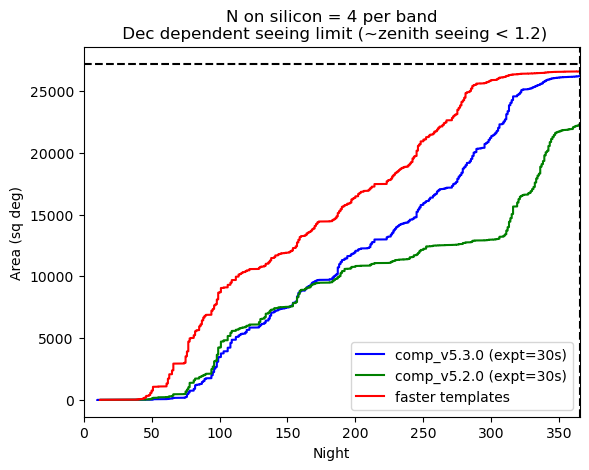

In [18]:
fig, ax = plt.subplots()


for key,co in zip(ar2label, colors):
    ack = arrays[key] +0 
    ack = np.sort(ack)
    ax.plot(ack, np.arange(ack.size)*hp.nside2pixarea(nside, degrees=True), label=ar2label[key], color=co)
ax.set_xlim([0,365])
ax.set_xlabel("Night")
ax.set_ylabel("Area (sq deg)")
ax.set_title("N on silicon = %i per band\n Dec dependent seeing limit (~zenith seeing < 1.2)" % n_needed)
leg = ax.legend()
ax.axvline(x=365, linestyle="--", color="k")
ax.axhline(y=fp_area, linestyle="--", color="k")

In [19]:
# Let's check the coverage per filter
db_file = "comp_survey_v5.3.0_10yrs.db"
run_name = db_file.replace(".db", "")
pb_arr = {}
pb_infos = {}
visits_array, run_name = read_sim(db_file)
for bandname in 'ugrizy':
    info = {"run_name": run_name}
    sub_data = visits_array[np.where(visits_array["visitExposureTime"] >=19.)]
    info["observations_subset"] = "expt > 19s"
    sl = maf.Slicer(nside=nside)
    # XXX--setting to 4 for now to try and cut down the missing area a bit
    metric = TemplateTime(nside=nside, n_needed=n_needed, bands=bandname, footprints=sky_maps)
    hp_array, info = sl(visits_array, metric, info=info)
    pb_arr[bandname] = hp_array
    pb_infos[bandname] = info

In [20]:
per_band = {}
for bandname in 'ugrizy':
    
    good = np.where((sky_maps[bandname] > 0) & (pb_arr[bandname] <= 365))[0]
    per_band[bandname] = good.size/np.where(sky_maps[bandname] > 0)[0].size

In [21]:
per_band

{'u': 0.9890086883701456,
 'g': 0.9893808314747216,
 'r': 0.9972371640028709,
 'i': 0.9920356236060413,
 'z': 0.9943817189779051,
 'y': 0.9976098258836665}

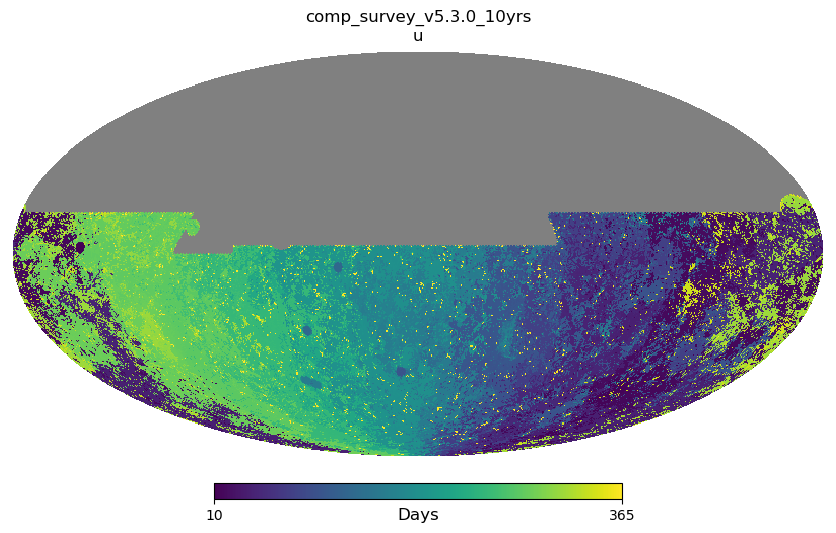

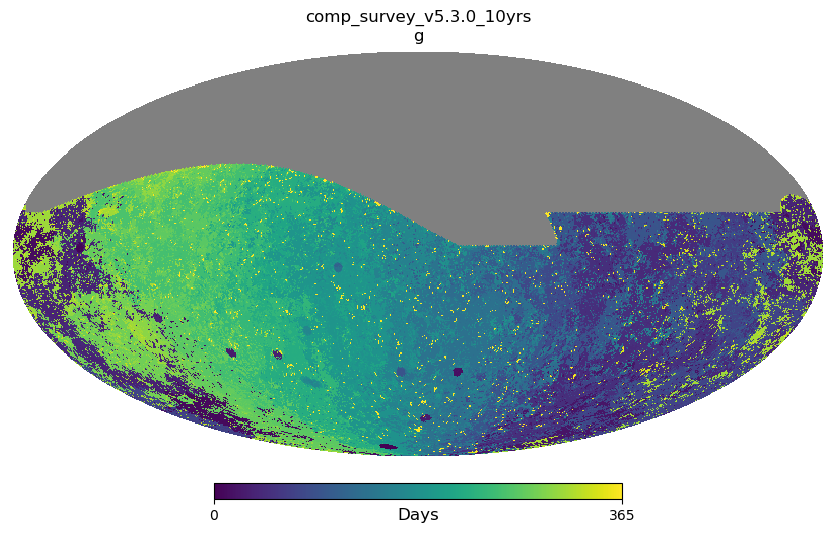

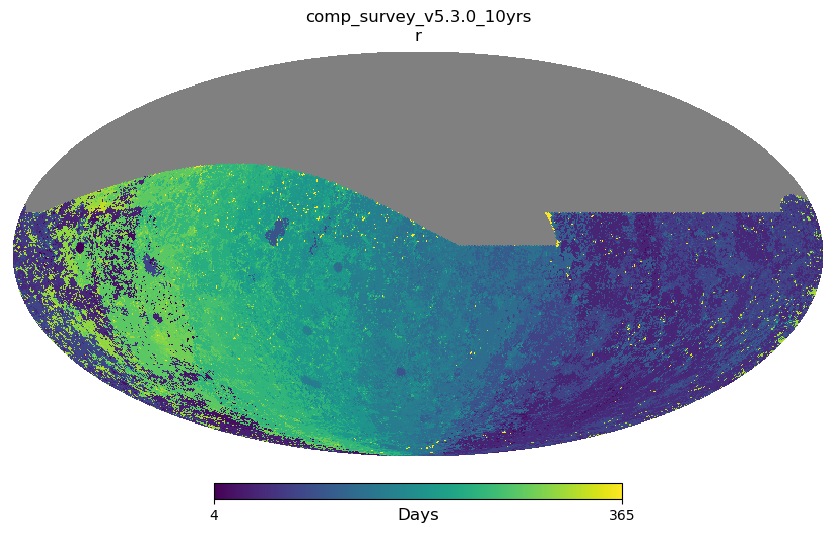

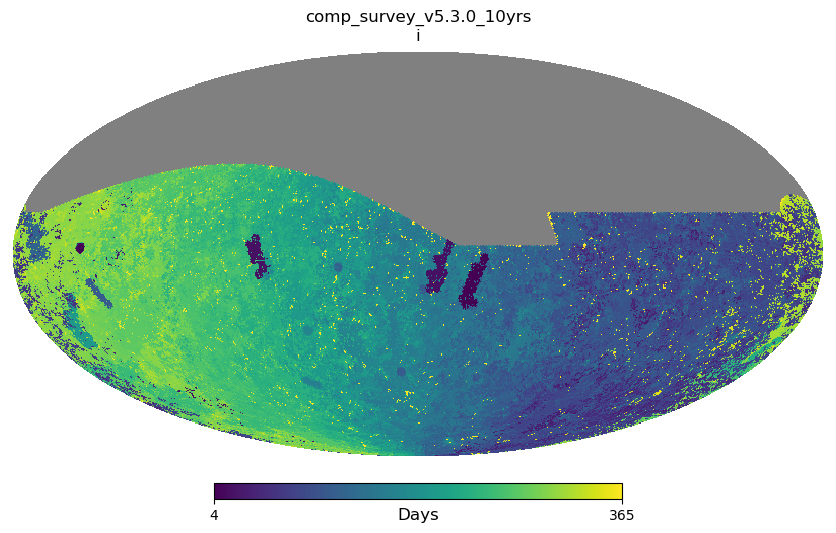

In [22]:
for bandname in 'ugri':

    hp.mollview(pb_arr[bandname], max=365, title=run_name + "\n"+bandname, unit="Days")